In [1]:
import numpy as np
import pandas as pd 

In [2]:
!pip install xgboost

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn import metrics

In [4]:
# importing data ----------->
data= pd.read_csv('house_prices.csv')

In [5]:
data.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [6]:
data.set_index('Index', inplace= True)

In [7]:
data.head()

,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
Index,,,,,,,,,,,,,,,,,,,,
0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [8]:
data.shape

(187531, 20)

In [9]:
#Preprocessing---------->
#--------------------------------
#checking null values
data.isnull().sum()

Title                     0
Description            3023
Amount(in rupees)         0
Price (in rupees)     17665
location                  0
Carpet Area           80673
Status                  615
Floor                  7077
Transaction              83
Furnishing             2897
facing                70233
overlooking           81436
Society              109678
Bathroom                828
Balcony               48935
Car Parking          103357
Ownership             65517
Super Area           107685
Dimensions           187531
Plot Area            187531
dtype: int64

In [10]:
data.drop(columns='Society',inplace=True)
data.drop(columns='Dimensions',inplace=True)
data.drop(columns='Plot Area',inplace=True)

In [11]:
data['Description'] = data['Description'].fillna('No description')

In [12]:
# converting strings in these columns to numeric values
num_cols = ['Bathroom', 'Balcony']

for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce', )

In [13]:
data['Bathroom'] = data['Bathroom'].fillna(data['Bathroom'].median())
data['Balcony'] = data['Balcony'].fillna(data['Balcony'].median())


In [14]:
# extracting numericals only cuz these columns contain mixed values of string and numerics.

data['Super Area'] = data['Super Area'].str.extract(r'(\d+\.?\d*)')
data['Carpet Area'] = data['Carpet Area'].str.extract(r'(\d+\.?\d*)')
data['Car Parking'] = data['Car Parking'].str.extract(r'(\d+\.?\d*)')

In [15]:
cols = ['Super Area', 'Carpet Area', 'Car Parking']

for col in cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')

In [16]:
data['Car Parking'] = data['Car Parking'].fillna(data['Car Parking'].median())
data['Super Area'] = data['Super Area'].fillna(data['Super Area'].median())
data['Carpet Area'] = data['Carpet Area'].fillna(data['Carpet Area'].median())

In [17]:
data['Ownership'] = data['Ownership'].fillna(data['Ownership'].mode()[0])
data['facing'] = data['facing'].fillna(data['facing'].mode()[0])
data['overlooking'] = data['overlooking'].fillna(data['overlooking'].mode()[0])

In [18]:
data.isnull().sum()

Title                    0
Description              0
Amount(in rupees)        0
Price (in rupees)    17665
location                 0
Carpet Area              0
Status                 615
Floor                 7077
Transaction             83
Furnishing            2897
facing                   0
overlooking              0
Bathroom                 0
Balcony                  0
Car Parking              0
Ownership                0
Super Area               0
dtype: int64

In [19]:
cat_cols = ['Status', 'Transaction', 'Furnishing']

for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [20]:
data.isnull().sum()

Title                    0
Description              0
Amount(in rupees)        0
Price (in rupees)    17665
location                 0
Carpet Area              0
Status                   0
Floor                 7077
Transaction              0
Furnishing               0
facing                   0
overlooking              0
Bathroom                 0
Balcony                  0
Car Parking              0
Ownership                0
Super Area               0
dtype: int64

In [21]:
#dropping rows with empty floor values

data = data.dropna(subset=['Floor'])
data = data.dropna(subset=['Price (in rupees)'])

In [22]:
data.isnull().sum()

Title                0
Description          0
Amount(in rupees)    0
Price (in rupees)    0
location             0
Carpet Area          0
Status               0
Floor                0
Transaction          0
Furnishing           0
facing               0
overlooking          0
Bathroom             0
Balcony              0
Car Parking          0
Ownership            0
Super Area           0
dtype: int64

In [23]:
data = data.drop(columns=['Title', 'Description', 'Price (in rupees)'])

In [25]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['location', 'Status', 'Floor','Transaction', 'Furnishing', 'facing', 'overlooking', 'Ownership']

le = LabelEncoder()

for col in cat_cols:
    data[col] = le.fit_transform(data[col].astype(str))

In [27]:
def convert_amount(x):
    
    x = str(x).strip()
    
    if 'Cr' in x:
        return float(x.replace('Cr', '').strip()) * 10000000
    
    elif 'Lac' in x:
        return float(x.replace('Lac', '').strip()) * 100000
    
    else:
        return None

In [28]:
data['Amount(in rupees)'] = data['Amount(in rupees)'].apply(convert_amount)

In [55]:
data = pd.get_dummies(data,columns=['location', 'Status', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Ownership'], drop_first=True)

In [75]:
data = data.drop(columns=['Floor'])

In [76]:
#Statistical measures of data------------->

In [77]:
data.head()

,Amount(in rupees),Carpet Area,Bathroom,Balcony,Car Parking,Super Area,location_1,location_2,location_3,location_4,...,overlooking_11,overlooking_12,overlooking_13,overlooking_14,overlooking_15,overlooking_16,overlooking_17,Ownership_1,Ownership_2,Ownership_3
Index,,,,,,,,,,,,,,,,,,,,,
0,4200000.0,500.0,1.0,2.0,1.0,1250.0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,9800000.0,473.0,2.0,2.0,1.0,1250.0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,14000000.0,779.0,2.0,2.0,1.0,1250.0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,16000000.0,635.0,2.0,2.0,1.0,1250.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,4500000.0,1000.0,1.0,1.0,1.0,680.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [78]:
data.shape

(163023, 118)

In [79]:
data.describe()

,Amount(in rupees),Carpet Area,Bathroom,Balcony,Car Parking,Super Area
count,1.630230e+05,163023.000000,163023.000000,163023.000000,163023.000000,163023.000000
mean,1.194116e+07,1122.236329,2.440723,2.030327,2.454936,1272.795133
std,4.096392e+07,2442.439346,0.850626,0.831278,22.001944,454.257242
min,1.000000e+05,1.000000,1.000000,1.000000,1.000000,1.000000
25%,4.860000e+06,1000.000000,2.000000,1.000000,1.000000,1250.000000
50%,7.800000e+06,1000.000000,2.000000,2.000000,1.000000,1250.000000
75%,1.500000e+07,1150.000000,3.000000,2.000000,1.000000,1250.000000
max,1.400300e+10,709222.000000,10.000000,10.000000,999.000000,9450.000000


In [80]:
#plot the heatmap

correlation= data.select_dtypes(include=['number']).corr()

<Axes: >

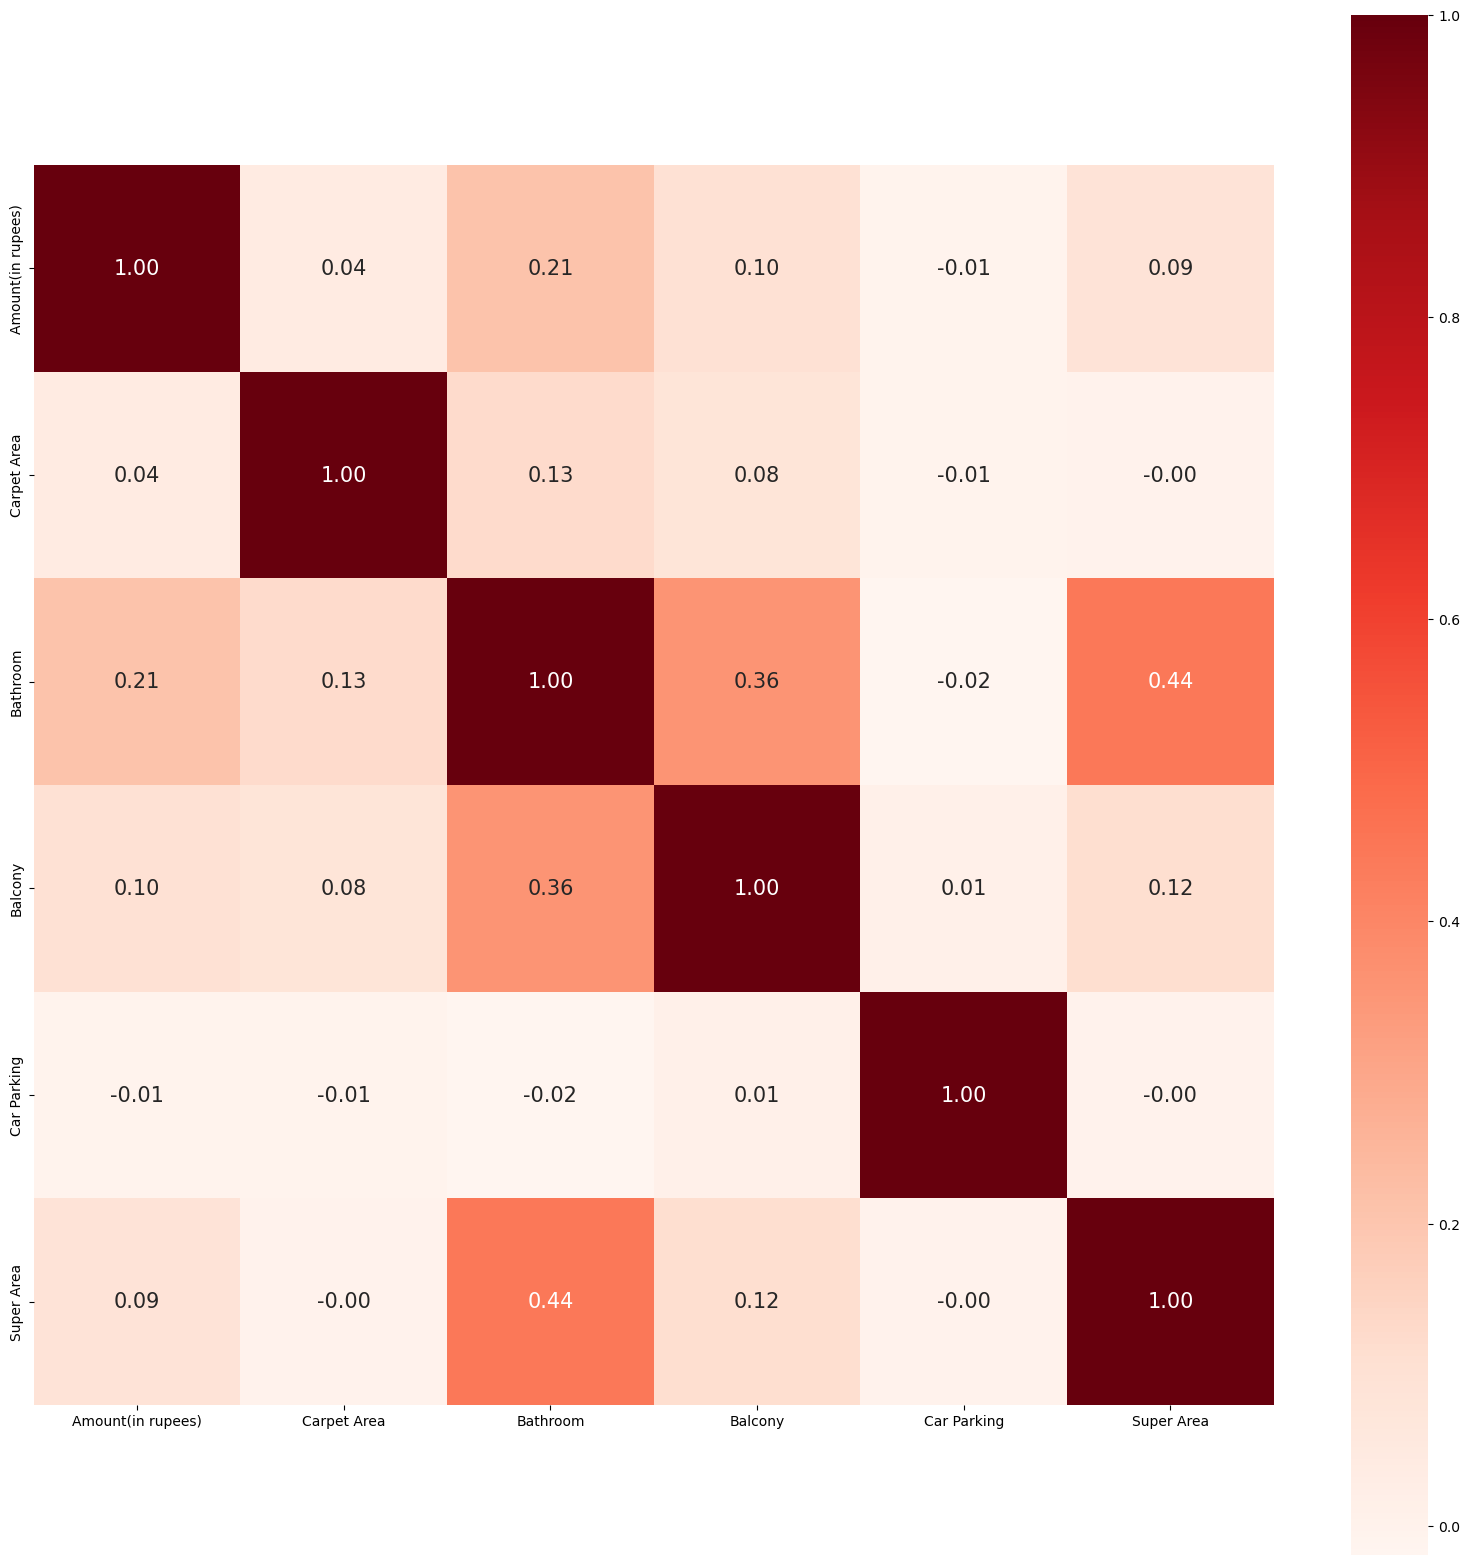

In [81]:
plt.figure(figsize=(20,20))
sns.heatmap(correlation, cbar= True, square= True, fmt='.2f', annot= True, annot_kws={'size':15}, cmap='Reds')

In [82]:
#splitting the data----->


In [96]:
X = data.drop(columns=['Amount(in rupees)'])

Y = np.log1p(data['Amount(in rupees)'])

In [97]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=3)

In [104]:
model = xgb.XGBRegressor()

In [109]:
model.fit(X_train,Y_train,)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [110]:
train_pred = model.predict(X_train)
print(train_pred)

[17.135178 15.697507 16.414856 ... 16.637127 15.438447 15.406801]


In [111]:
score_1 = metrics.r2_score(Y_train, train_pred)
score_2 = metrics.mean_absolute_error(Y_train, train_pred)

print("R2 error on training data :", score_1)
print("MAE on training data:", score_2)

R2 error on training data : 0.9330455263921911
MAE on training data: 0.12317957211436505


In [112]:
test_pred = model.predict(X_test)
print(test_pred)

[17.027641 17.73568  17.158691 ... 16.000973 16.933773 16.543068]


In [113]:
score_3 = metrics.r2_score(Y_test, test_pred)
score_4 = metrics.mean_absolute_error(Y_test, test_pred)

print("R2 error on testing data :", score_3)
print("MAE on testing data:", score_4)

R2 error on testing data : 0.9232567149442865
MAE on testing data: 0.12857014510126843


In [ ]:
#without log transformation data was so noisy that results were very low cuz of high data values
#log transformation compressed data values and decreased noise

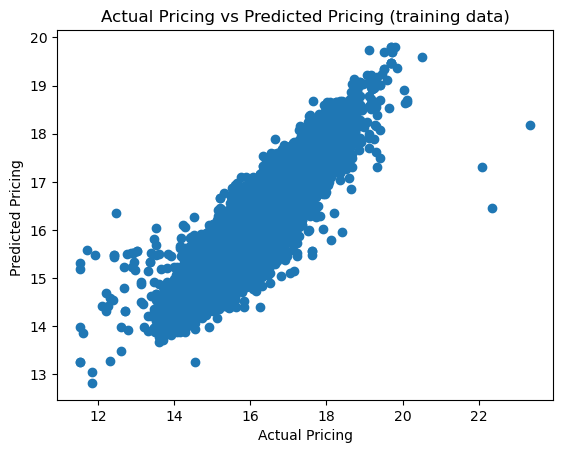

In [120]:
#plotting model predictions on traning data

plt.scatter(Y_train ,train_pred)
plt.xlabel('Actual Pricing')
plt.ylabel('Predicted Pricing ')
plt.title("Actual Pricing vs Predicted Pricing (training data)")
plt.show()

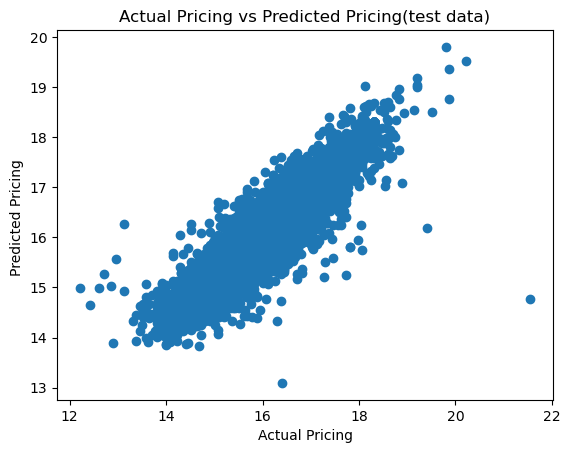

In [118]:
#plotting model predictions on testing data

plt.scatter(Y_test ,test_pred)
plt.xlabel('Actual Pricing')
plt.ylabel('Predicted Pricing ')
plt.title("Actual Pricing vs Predicted Pricing(test data)")
plt.show()

In [ ]:
#ayyyyyyy finally completedd